---

<div align="center">

# ***Prueba yfinance***

</div>

---

## Librerias

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from matplotlib.ticker import FuncFormatter
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

## Data

In [3]:
indices = {
    # Índices de EE.UU.
    "^GSPC": "S&P 500 (EE.UU.)",
    "^DJI": "Dow Jones Industrial Average (EE.UU.)",
    "^IXIC": "NASDAQ Composite (EE.UU.)",
    "^NYA": "NYSE Composite (EE.UU.)",
    "^RUT": "Russell 2000 (EE.UU.)",
    "^VIX": "CBOE Volatility Index (EE.UU.)",
    "^XAX": "NYSE AMEX Composite Index (EE.UU.)",
    "^BUK100P": "Cboe UK 100 (EE.UU.)",

    # Índices de Canadá
    "^GSPTSE": "S&P/TSX Composite Index (Canadá)",

    # Índices de Europa
    "^FTSE": "FTSE 100 (Reino Unido)",
    "^GDAXI": "DAX (Alemania)",
    "^FCHI": "CAC 40 (Francia)",
    "^STOXX50E": "Euro Stoxx 50 (Europa)",
    "^IBEX": "IBEX 35 (España)",
    "^N100": "Euronext 100 (Europa)",
    "^BFX": "BEL 20 (Bélgica)",
    "^ATX": "Austrian Traded Index (Austria)",
    "^OMXC20": "OMX Copenhagen 20 (Dinamarca)",
    "^OSEAX": "Oslo Børs All-Share Index (Noruega)",
    "^SSMI": "Swiss Market Index (Suiza)",

    # Índices de Asia-Pacífico
    "^N225": "Nikkei 225 (Japón)",
    "^HSI": "Hang Seng Index (Hong Kong)",
    "000001.SS": "Shanghai Composite Index (China)",
    "399001.SZ": "Shenzhen Component Index (China)",
    "^STI": "Straits Times Index (Singapur)",
    "^AXJO": "S&P/ASX 200 (Australia)",
    "^AORD": "All Ordinaries (Australia)",
    "^BSESN": "S&P BSE SENSEX (India)",
    "^NSEI": "NIFTY 50 (India)",
    "^JKSE": "Jakarta Composite Index (Indonesia)",
    "^KLSE": "FTSE Bursa Malaysia KLCI (Malasia)",
    "^NZ50": "S&P/NZX 50 Index (Nueva Zelanda)",
    "^KS11": "KOSPI Composite Index (Corea del Sur)",
    "^TWII": "Taiwan Weighted Index (Taiwán)",

    # Índices de América Latina
    "^BVSP": "Bovespa Index (Brasil)",
    "^MXX": "IPC Mexico (México)",
    "^MERV": "MERVAL Index (Argentina)",
    "^IPSA": "S&P/CLX IPSA (Chile)",
    "^COLCAP": "COLCAP Index (Colombia)",
    "^IGBC": "Índice General de la Bolsa de Valores de Colombia (Colombia)",
    "^SPBLPGPT": "S&P/BVL Peru General Index (Perú)",

    # Índices de África y Medio Oriente
    "^CASE30": "EGX 30 Index (Egipto)",
    "^JN0U.JO": "Top 40 USD Net TRI Index (Sudáfrica)",
    "^TA125.TA": "TA-125 Index (Israel)",

    # ETFs de Bonos
    "AGG": "iShares Core U.S. Aggregate Bond ETF",
    "BND": "Vanguard Total Bond Market ETF",
    "TLT": "iShares 20+ Year Treasury Bond ETF",
    "SHY": "iShares 1-3 Year Treasury Bond ETF",
    "LQD": "iShares iBoxx $ Investment Grade Corporate Bond ETF",
    "HYG": "iShares iBoxx $ High Yield Corporate Bond ETF",
    "IBND": "SPDR Bloomberg International Corporate Bond ETF",

    # ETFs de Oro y Metales Preciosos
    "GLD": "SPDR Gold Shares ETF",
    "IAU": "iShares Gold Trust ETF",
    "IAUF": "iShares Gold Strategy ETF",
    "AAAU": "Goldman Sachs Physical Gold ETF",
    "GOAU": "U.S. Global GO GOLD and Precious Metal Miners ETF",
    "RING": "iShares MSCI Global Gold Miners ETF",

    # Futuros de Commodities
    "GC=F": "Oro - Futuros",
    "SI=F": "Plata - Futuros",
    "PL=F": "Platino - Futuros",
    "HG=F": "Cobre - Futuros",
    "CL=F": "Petróleo Crudo WTI - Futuros",
    "BZ=F": "Petróleo Brent - Futuros",
    "NG=F": "Gas Natural - Futuros",
    "ZC=F": "Maíz - Futuros",
    "ZW=F": "Trigo - Futuros",
    "ZS=F": "Soja - Futuros",
    "CC=F": "Cacao - Futuros",
    "KC=F": "Café - Futuros",
    "SB=F": "Azúcar - Futuros",
    "CT=F": "Algodón - Futuros",
    "LB=F": "Madera - Futuros",

    # ETFs de Commodities
    "USO": "United States Oil Fund ETF",
    "UNG": "United States Natural Gas Fund ETF",
    "SLV": "iShares Silver Trust ETF",
    "DBC": "Invesco DB Commodity Index Tracking Fund",

    # Índices de Commodities
    "^BCOM": "Bloomberg Commodity Index",
}

In [4]:
simbolo = "DBC"  # Puedes cambiar esto a cualquier otro índice

df = yf.Ticker(simbolo).history(period="max")

info = yf.Ticker(simbolo).info
nombre_indice = info.get('shortName', simbolo) 

## **Graficas**

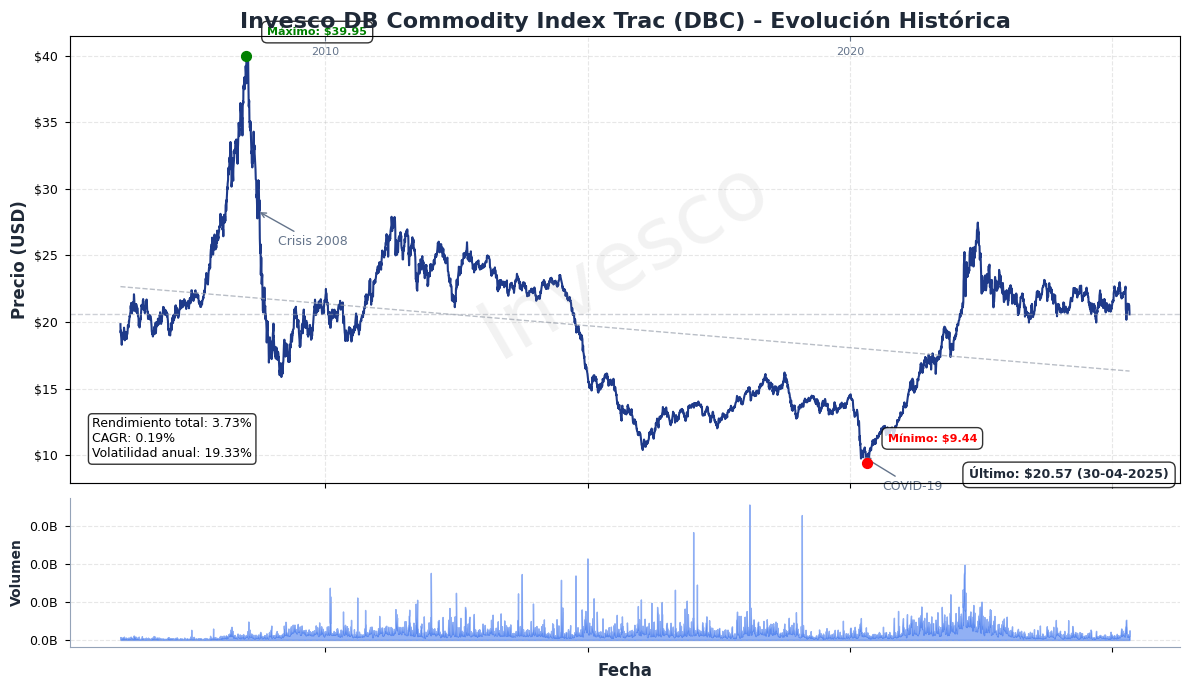

In [5]:
plt.style.use('default')  # Resetear estilo para tener un fondo blanco
fig = plt.figure(figsize=(12, 7), dpi=100)
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])

# Gráfico principal de precios
ax1 = plt.subplot(gs[0])

# Color para el gráfico principal - azul financiero
color_principal = '#1E3A8A'

# Graficar el precio de cierre
ax1.plot(df.index, df['Close'], color=color_principal, linewidth=1.5)

# Añadir línea de tendencia (regresión polinómica)
x = np.arange(len(df.index))
z = np.polyfit(x, df['Close'], 1)
p = np.poly1d(z)
ax1.plot(df.index, p(x), "--", color="#9CA3AF", linewidth=1, alpha=0.7)

# Configurar ejes y título dinámico basado en el índice consultado
ax1.set_ylabel('Precio (USD)', fontsize=12, fontweight='bold', color='#1F2937')
ax1.set_title(f'{nombre_indice} ({simbolo}) - Evolución Histórica', fontsize=16, fontweight='bold', color='#1F2937')

# Formatear eje Y con separador de miles
def price_formatter(x, pos):
    return f'${x:,.0f}'

ax1.yaxis.set_major_formatter(FuncFormatter(price_formatter))

# Configurar cuadrícula suave
ax1.grid(True, linestyle='--', alpha=0.3)

# Configurar fechas en el eje X
ax1.xaxis.set_major_locator(mdates.YearLocator(5))  # Mostrar cada 5 años
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Obtener la zona horaria del índice del dataframe para usarla en las fechas de eventos
tz = df.index[0].tz

# Añadir anotaciones de eventos importantes
eventos = [
    ("Crisis punto com", "2000-03-24", 1527.46),
    ("Crisis 2008", "2008-09-15", 1192.70),
    ("COVID-19", "2020-03-23", 2237.40),
]

for nombre, fecha, precio in eventos:
    try:
        # Convertir fecha a datetime con la misma zona horaria que los datos
        fecha_dt = pd.to_datetime(fecha).tz_localize(tz)
        
        # Verificar si la fecha está dentro del rango de datos
        if fecha_dt >= df.index[0] and fecha_dt <= df.index[-1]:
            # Encontrar la fecha más cercana en el dataframe
            idx = df.index[df.index.get_indexer([fecha_dt], method='nearest')[0]]
            precio_real = df.loc[idx, 'Close']
            
            ax1.annotate(nombre, 
                        xy=(idx, precio_real),
                        xytext=(15, -25),
                        textcoords='offset points',
                        arrowprops=dict(arrowstyle='->', color='#64748B'),
                        fontsize=9,
                        color='#64748B')
    except Exception as e:
        print(f"No se pudo añadir anotación para el evento {nombre}: {e}")
        
# Gráfico de volumen abajo
ax2 = plt.subplot(gs[1], sharex=ax1)
ax2.fill_between(df.index, df['Volume'], color='#2563EB', alpha=0.5)
ax2.set_ylabel('Volumen', fontsize=10, fontweight='bold', color='#1F2937')
ax2.tick_params(axis='y', labelsize=8)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1e9:.1f}B'))
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# Identificar máximos y mínimos históricos
maximo = df['Close'].max()
fecha_max = df.loc[df['Close'] == maximo].index[0]
minimo = df['Close'].min()
fecha_min = df.loc[df['Close'] == minimo].index[0]

# Destacar máximo y mínimo
ax1.scatter(fecha_max, maximo, color='green', s=50, zorder=5)
ax1.scatter(fecha_min, minimo, color='red', s=50, zorder=5)

# Añadir anotaciones de máximo y mínimo
ax1.annotate(f'Máximo: ${maximo:.2f}',
            xy=(fecha_max, maximo),
            xytext=(15, 15),
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8),
            fontsize=8,
            fontweight='bold',
            color='green')

ax1.annotate(f'Mínimo: ${minimo:.2f}',
            xy=(fecha_min, minimo),
            xytext=(15, 15),
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8),
            fontsize=8,
            fontweight='bold',
            color='red')

# Añadir estadísticas resumidas
rendimiento_total = ((df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1) * 100
cagr = (pow(df['Close'].iloc[-1] / df['Close'].iloc[0], 1 / (len(df) / 252)) - 1) * 100
volatilidad = df['Close'].pct_change().std() * np.sqrt(252) * 100

info_text = (f"Rendimiento total: {rendimiento_total:.2f}%\n"
            f"CAGR: {cagr:.2f}%\n"
            f"Volatilidad anual: {volatilidad:.2f}%")

# Añadir texto con estadísticas en un recuadro
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax1.text(0.02, 0.05, info_text, transform=ax1.transAxes, fontsize=9,
        verticalalignment='bottom', bbox=props)

# Añadir marca de agua con estilo profesional (usando el nombre corto del índice)
nombre_corto = nombre_indice.split(' ')[0] if ' ' in nombre_indice else nombre_indice
ax1.text(0.5, 0.5, nombre_corto,
        fontsize=60, color='gray', alpha=0.1,
        ha='center', va='center', rotation=30, transform=ax1.transAxes)

# Añadir línea horizontal que indica el nivel actual
ax1.axhline(y=df['Close'].iloc[-1], color='#9CA3AF', alpha=0.5, linestyle='--', linewidth=1)

# Añadir un segundo eje X en la parte superior para mostrar las fechas
ax1_top = ax1.twiny()
ax1_top.set_xlim(ax1.get_xlim())
ax1_top.xaxis.set_major_locator(mdates.YearLocator(10))  # Cada 10 años
ax1_top.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1_top.tick_params(axis='x', direction='in', pad=-15, labelsize=8, colors='#64748B')

# Configurar ticks y bordes
for ax in [ax1, ax2]:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=9)
    ax.spines['left'].set_color('#94A3B8')
    ax.spines['bottom'].set_color('#94A3B8')

# Añadir información de la última actualización
ultima_fecha = df.index[-1].strftime('%d-%m-%Y')
ultimo_precio = df['Close'].iloc[-1]
ax1.annotate(f'Último: ${ultimo_precio:.2f} ({ultima_fecha})',
            xy=(0.99, 0.01),
            xycoords='axes fraction',
            ha='right',
            fontsize=9,
            fontweight='bold',
            color='#1F2937',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))

# Estrechar horizontalmente los ticks del eje Y
ax1.tick_params(axis='y', which='both', pad=5)
ax2.tick_params(axis='y', which='both', pad=5)

# Eliminar etiqueta x del gráfico superior
ax1.xaxis.set_ticklabels([])
ax1.set_xlabel('')

# Configurar etiqueta x del gráfico inferior
ax2.set_xlabel('Fecha', fontsize=12, fontweight='bold', color='#1F2937')

plt.tight_layout()
plt.subplots_adjust(hspace=0.05)  # Reducir espacio entre subplots para que se vean unidos

# Mostrar la gráfica
plt.show()